## Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import h5py  
import seaborn as sns
from scipy.special import betaincinv
import scipy.stats as stats


from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata.utils import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck15  
from astropy.table import Table

import pdb
 
import torch
from typing import Optional, Tuple
from torch import Tensor

import pickle


import os
import sys
sys.path.append(r"C:\Users\usuario\Documents\TFG\florah\src")

from florah.models.rnn_model.rnn_generator import DataModule 


#import sklearn
#import plotly.express as px


In [2]:
def build_features(cosmos_cat,zbin,node_features):
    x = node_features['x']   # halo mass and concentration
    t = node_features['t']
    ra =   node_features['ra']
    dec = node_features['dec']
    sersic = node_features['sersic']
    bovert = node_features['bovert']
    morphology = node_features['morphology']
    idnumber = node_features['id']

    x_updated=[]
    t_updated=[]
    ra_updated=[]
    dec_updated=[]
    sersic_updated=[]
    bovert_updated=[]
    morphology_updated=[]
    id_updated=[]

    sel2_len_vec=[]
    n_chunks = len(x)

    for id_data, x_data, t_data,ra_data,dec_data,sersic_data, bovert_data, morphology_data in zip(idnumber,x,t,ra,dec,sersic,bovert, morphology):
        mass_last = x_data[-1,0]
        # we select galaxies with the following characteristics:
        sel2 = cosmos_cat.query("sfr_CIGALE > -15 and radius_sersic > 0  and mass_CIGALE>"+str(mass_last-1.5)+" and mass_CIGALE<"+str(mass_last+1.5)+ " and zpdf_med>"+str(zbin[0])+" and zpdf_med<"+str(zbin[1]))
        # we reduce sample size
        size_sample = int(len(sel2)*0.003)
        sel2 = sel2.sample(n=size_sample)

        #chunks=0
        for i in range(len(sel2)):
            new_entry  = [sel2['mass_CIGALE'].values[i], np.log10(Planck15.angular_diameter_distance(sel2.zpdf_med.values[i]).value * np.deg2rad(sel2.radius_sersic.values[i]) * 1e3), sel2['sfr_CIGALE'].values[i]] #log10 of stellar mass, galaxy radius and sfr, respectively.
            new_x = np.vstack([x_data, new_entry])

            new_entry = [1/(1+sel2.zpdf_med.values[i])] 
            new_t = np.vstack([t_data,new_entry])

            new_entry = [sel2.ra.values[i]] 
            new_ra = np.vstack([ra_data,new_entry])

            new_entry = [sel2.dec.values[i]] 
            new_dec = np.vstack([dec_data,new_entry])

            new_entry = [sel2.sersic.values[i]] 
            new_sersic = np.vstack([sersic_data,new_entry])

            new_entry = [sel2['b/t_f444w'].values[i]] 
            new_bovert = np.vstack([bovert_data,new_entry])

            new_entry = [sel2['morph_flag_f444w'].values[i]] 
            new_morphology= np.vstack([morphology_data,new_entry])

            new_entry = [sel2['id'].values[i]] 
            new_id= np.vstack([id_data,new_entry])

            #pdb.set_trace()

            # Convert the 'x_data' to a list of floats while ignoring non-numeric and 'inf' values and skipping the first row
            cleaned_x_mass = [float(value) for value in (new_x[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_x_size = [float(value) for value in (new_x[0:,1]) if value != b'-' and value != b'-inf']
            cleaned_x_sfr = [float(value) for value in (new_x[0:,2]) if value != b'-' and value != b'-inf']
            x_copy = np.column_stack([cleaned_x_mass, cleaned_x_size, cleaned_x_sfr])

            cleaned_t = [float(value) for value in (new_t[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_t = np.expand_dims(cleaned_t,1)

            cleaned_ra = [float(value) for value in (new_ra[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_ra = np.expand_dims(cleaned_ra,1)

            cleaned_dec = [float(value) for value in (new_dec[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_dec = np.expand_dims(cleaned_dec,1)

            cleaned_sersic = [float(value) for value in (new_sersic[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_sersic = np.expand_dims(cleaned_sersic,1)

            cleaned_bovert = [float(value) for value in (new_bovert[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_bovert = np.expand_dims(cleaned_bovert,1)

            cleaned_morphology = [float(value) for value in (new_morphology[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_morphology = np.expand_dims(cleaned_morphology,1)

            cleaned_id = [float(value) for value in (new_id[0:,0]) if value != b'-' and value != b'-inf']
            cleaned_id = np.expand_dims(cleaned_id,1)

            x_updated.append(x_copy)
            t_updated.append(cleaned_t)
            ra_updated.append(cleaned_ra)
            dec_updated.append(cleaned_dec)
            sersic_updated.append(cleaned_sersic)
            bovert_updated.append(cleaned_bovert)
            morphology_updated.append(cleaned_morphology)
            id_updated.append(cleaned_id)
            #chunks+=1
            #pdb.set_trace()

        sel2_len_vec.append(len(sel2)) # we store len(sel2) for every iteration
        #if (len(sel2)!=chunks):
            #pdb.set_trace()
            #print('weird')
        

    # Store 'x_copy' and 't' data as lists of NumPy arrays in the 'node_features' dictionary
    node_features = {'id': [np.array(arr, dtype=np.float32) for arr in id_updated],'x': [np.array(arr, dtype=np.float32) for arr in x_updated], 't': [np.array(arr, dtype=np.float32) for arr in t_updated],'ra': [np.array(arr, dtype=np.float32) for arr in ra_updated],'dec': [np.array(arr, dtype=np.float32) for arr in dec_updated],'sersic': [np.array(arr, dtype=np.float32) for arr in sersic_updated],'bovert': [np.array(arr, dtype=np.float32) for arr in bovert_updated],'morphology': [np.array(arr, dtype=np.float32) for arr in morphology_updated]}
    #print("after features:", len(x_updated))
    return node_features, n_chunks, sel2_len_vec
           



def build_roots(cosmos_cat,mass_bin,nsamples=100,zbins=[0,0.5,1]):
    # we select galaxies with the following characteristics:
    sel = cosmos_cat.query("sfr_CIGALE > -15 and radius_sersic > 0  and mass_CIGALE > "+str(mass_bin[0])+" and mass_CIGALE < " + str(mass_bin[1])+" and zpdf_med > "+str(zbins[0])+" and zpdf_med < "+str(zbins[1]))
    # we shuffle the order of the galaxies selected:
        ##### i think this way we reduce the chance that the model might learn from order 
    if len(sel)<nsamples:
        sel = sel.sample(frac=1)
    else:
        sel = sel.sample(nsamples)
    n_chunks = len(sel)
    x = []
    t = []
    ravec=[]
    decvec=[]
    sersicvec=[]
    bovertvec=[]
    morphologyvec=[]
    len_sel2_vec=[]
    idvec = []
    node_features = {'x': None, 't': None, 'ra': None, 'dec': None}
    for idnumber, mass, z, re, ra, dec, SFR, sersic, bovert, morphology in zip(sel['id'].values, sel['mass_CIGALE'].values, sel.zpdf_med.values, sel.radius_sersic.values, sel.ra.values, sel.dec.values, sel['sfr_CIGALE'].values, sel.sersic.values, sel['b/t_f444w'].values, sel['morph_flag_f444w'].values):
        x_data=np.zeros((2,3))
        t_data=np.zeros(2)
        ra_data = np.zeros(2)
        dec_data = np.zeros(2)
        sersic_data= np.zeros(2)
        bovert_data=np.zeros(2)
        morphology_data =np.zeros(2)
        id_data = np.zeros(2)
        
        x_data[0,0]= mass
        x_data[0,1]= Planck15.angular_diameter_distance(z).value * np.deg2rad(re) * 1e3
        x_data[0,2]= SFR

        t_data[0] = 1/(1+z) 
        ra_data[0] = ra
        dec_data[0] = dec
        sersic_data[0]=sersic
        bovert_data[0]=bovert
        morphology_data[0]=morphology 
        id_data[0]=idnumber

        sel2 =  cosmos_cat.query("sfr_CIGALE > -15 and radius_sersic > 0  and mass_CIGALE>"+str(mass-1.5)+ " and mass_CIGALE<"+str(mass+0.5)+" and zpdf_med>"+str(zbins[1])+" and zpdf_med<"+str(zbins[2]))
        sel2 = sel2.sample(frac=0.03)
        chunks=0
        
        for i in range(len(sel2)):
            #print(x_data[0,0])
            #print((sel2.logM_50.values[i]-np.log10(2)-x_data[0,0]))
            # Append 'x_data' and 't_data' for the current galaxy in the second bin
            #if (sel2.logM_50.values[i]-np.log10(2)-x_data[0,0])>0.2 or (sel2.logM_50.values[i]-np.log10(2)-x_data[0,0])<-2:
             #   continue

            #print('here')     
            x_data[1,0]= sel2['mass_CIGALE'].values[i]
            x_data[1,1]= Planck15.angular_diameter_distance(sel2.zpdf_med.values[i]).value * np.deg2rad(sel2.radius_sersic.values[i]) * 1e3
            x_data[1,2]= sel2['sfr_CIGALE'].values[i]

            t_data[1]=1/(1+sel2.zpdf_med.values[i])  
            ra_data[1] = sel2.ra.values[i]
            dec_data[1] =sel2.dec.values[i]
            sersic_data[1]=sel2.sersic.values[i]
            bovert_data[1]=sel2['b/t_f444w'].values[i]
            morphology_data[1]=sel2['morph_flag_f444w'].values[i]
            id_data[1]=sel2['id'].values[i]

            # Convert the 'x_data' to a list of floats while ignoring non-numeric and 'inf' values and skipping the first row
            cleaned_x_mass = [float(value) for value in (x_data[0:,0]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_x_size = [float(value) for value in (x_data[0:,1]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_x_SFR = [float(value) for value in (x_data[0:,2]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
           
            if len(cleaned_x_SFR) != len(x_data):
                print('caution!')
            x_copy = np.column_stack([cleaned_x_mass, np.log10(cleaned_x_size), cleaned_x_SFR])

            # Convert the 't_data' to a list of floats while ignoring non-numeric and 'inf' values and skipping the first row
            cleaned_t = [float(value) for value in (t_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_t = np.expand_dims(cleaned_t,1)

            cleaned_ra = [float(value) for value in (ra_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_ra = np.expand_dims(cleaned_ra,1)
            

            cleaned_dec = [float(value) for value in (dec_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_dec = np.expand_dims(cleaned_dec,1)

            cleaned_sersic = [float(value) for value in (sersic_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_sersic = np.expand_dims(cleaned_sersic,1)

            cleaned_bovert = [float(value) for value in (bovert_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_bovert = np.expand_dims(cleaned_bovert,1)

            cleaned_morphology = [float(value) for value in (morphology_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_morphology = np.expand_dims(cleaned_morphology,1)

            cleaned_id = [float(value) for value in (id_data[0:]) if value not in (b'-', b'-inf') and not np.isnan(v := float(value))]
            cleaned_id = np.expand_dims(cleaned_id,1)
           
            # Append the cleaned 'x' and 't' data to their respective lists
            x.append(x_copy)
            t.append(cleaned_t)
            ravec.append(cleaned_ra)
            decvec.append(cleaned_dec)
            sersicvec.append(cleaned_sersic)
            bovertvec.append(cleaned_bovert)
            morphologyvec.append(cleaned_morphology)
            idvec.append(cleaned_id)
            #print('x_copy:', x_copy.shape)
            chunks+=1
        len_sel2_vec.append(chunks)
        if (len(sel2)!=chunks):
            print('weird')
        #print("lengths:",chunks,len(sel2))



    

    # Store 'x_copy' and 't' data as lists of NumPy arrays in the 'node_features' dictionary
    node_features = {'id': [np.array(arr, dtype=np.float32) for arr in idvec],'x': [np.array(arr, dtype=np.float32) for arr in x], 't': [np.array(arr, dtype=np.float32) for arr in t],'ra': [np.array(arr, dtype=np.float32) for arr in ravec],'dec': [np.array(arr, dtype=np.float32) for arr in decvec],'sersic': [np.array(arr, dtype=np.float32) for arr in sersicvec],'bovert': [np.array(arr, dtype=np.float32) for arr in bovertvec],'morphology': [np.array(arr, dtype=np.float32) for arr in morphologyvec]}
   
    return node_features,n_chunks,len_sel2_vec


In [3]:
def get_maxlike_descendant(l_numpy,node_features, num_chunks,chunk_size,step=1):

    x=node_features['x']
    t=node_features['t']
    ra=node_features['ra']
    dec=node_features['dec']
    sersic = node_features['sersic']
    bovert = node_features['bovert']
    morphology = node_features['morphology']
    idvec=node_features['id']
    # Calculate the number of chunks
    
    
    id_sel=[]
    x_sel=[]
    t_sel=[]
    ra_sel=[]
    dec_sel=[]
    sersic_sel=[]
    bovert_sel=[]
    morphology_sel=[]

    if step>1:
        l_numpy = l_numpy[step-1::step]
    #num_chunks = len(l_numpy) // chunk_size    
    start_idx =0
    end_idx=0
    for i in range(num_chunks):
        if i==0:
            start_idx=0
        else:
            start_idx = end_idx
        
        end_idx += chunk_size[i]
        #print(start_idx,end_idx)
        chunk = l_numpy[start_idx:end_idx]

        # Find the maximum value and its position in the chunk
        max_value = np.max(chunk)
        max_position = np.argmax(chunk)
        if len([start_idx + max_position])>1:
            print('weird!')
            

        x_sel.append(x[start_idx + max_position])
        t_sel.append(t[start_idx + max_position])
        ra_sel.append(ra[start_idx + max_position])
        dec_sel.append(dec[start_idx + max_position])
        sersic_sel.append(sersic[start_idx + max_position])
        bovert_sel.append(bovert[start_idx + max_position])
        morphology_sel.append(morphology[start_idx + max_position])
        id_sel.append(idvec[start_idx + max_position])

        
    node_features_updated = {'id': [np.array(arr, dtype=np.float32) for arr in id_sel], 'x': [np.array(arr, dtype=np.float32) for arr in x_sel], 't': [np.array(arr, dtype=np.float32) for arr in t_sel],'ra': [np.array(arr, dtype=np.float32) for arr in ra_sel],'dec': [np.array(arr, dtype=np.float32) for arr in dec_sel],'sersic': [np.array(arr, dtype=np.float32) for arr in sersic_sel],'bovert': [np.array(arr, dtype=np.float32) for arr in bovert_sel],'morphology': [np.array(arr, dtype=np.float32) for arr in morphology_sel]}
    #print("after max selection:", len(x_sel))
    return node_features_updated

In [4]:
def log_likelihood_obs(
        model: torch.nn.Module, batch: Tuple[Tensor],
        to_numpy: bool = True,  batch_size: int = 4096
    ):
    """ Sample trees using Recurrent-MAF model
    Parameters
    ----------
    model: torch.nn.Module
        Recurrent model
    roots: np.ndarray
        Root features
    times: np.ndarray
        Time features
    to_numpy: bool
        Whether to convert to numpy
    device: Optional
        Device to use
    batch_size: int

    Returns
    -------
    x: Union[Tensor, np.ndarray]
        Sampled trees
    """

    device ='cpu'
    model = model.to(device)

    #seq_len = len(roots)+1
    #mask = np.expand_dims(np.zeros(seq_len),axis=0)
    #mask = np.zeros((1, seq_len), dtype=np.bool)
    #mask[:, :seq_len] = True
    #t = np.concatenate((times, t_obs),axis=1)

    #x_tensor = torch.from_numpy(roots.astype('float32'))
    #y_tensor = torch.from_numpy(obs.astype('float32'))
    #t_tensor = torch.from_numpy(t.astype('float32'))
    #seq_len_tensor = torch.tensor(seq_len, dtype=torch.int32)
    #mask_tensor = torch.from_numpy(mask)

    #tensor_tuple = (x_tensor, y_tensor, t_tensor, seq_len_tensor, mask_tensor)

    lp=model.log_prob(batch,return_context=False)

   
    return lp

## Load data and model

In [5]:
# Load the trained model from a checkpoint file
checkpoint_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\last-v1.ckpt"  # Specify the path to your checkpoint file
loaded_model = DataModule.load_from_checkpoint(checkpoint_path,map_location='cpu', weights_only=False)


# Set the model to evaluation mode (important if you have dropout or batch normalization layers)
loaded_model.eval()

DataModule(
  (model): RecurrentMAF(
    (embedding_net): Identity()
    (rnn): ModuleList(
      (0): GRU(5, 128, batch_first=True)
      (1-3): 3 x GRU(128, 128, batch_first=True)
    )
    (maf_blocks): Flow(
      (_transform): CompositeTransform(
        (_transforms): ModuleList(
          (0): CompositeTransform(
            (_transforms): ModuleList(
              (0-3): 4 x CompositeTransform(
                (_transforms): ModuleList(
                  (0): MaskedAffineAutoregressiveTransform(
                    (autoregressive_net): MADE(
                      (initial_layer): MaskedLinear(in_features=3, out_features=128, bias=True)
                      (context_layer): Linear(in_features=128, out_features=128, bias=True)
                      (blocks): ModuleList(
                        (0-1): 2 x MaskedFeedforwardBlock(
                          (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
                          (line

In [6]:
cosmos_data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
cosmos_cat = pd.read_csv(cosmos_data_path+"COSMOSWeb_Laura_filtered.csv") # Data from COSMOS-WEB, converted from .fits to .csv in florah_eval_SFR.ipynb

sfr_CIGALE = np.log10(cosmos_cat['sfr_inst'].values)
mass_CIGALE = np.log10(cosmos_cat['mass'].values)

cosmos_cat['sfr_CIGALE'] = sfr_CIGALE
cosmos_cat['mass_CIGALE'] = mass_CIGALE


C:\Users\usuario\AppData\Local\Temp\ipykernel_17060\3503147425.py:4: RuntimeWarning: divide by zero encountered in log10
  sfr_CIGALE = np.log10(cosmos_cat['sfr_inst'].values)


In [7]:
print(f"Total de galaxias en el catálogo: {len(cosmos_cat)}")

Total de galaxias en el catálogo: 784016


#### Get files with predictions on progenitor-descendant


In [8]:
#redshifts = np.array([1.5,2,2.5,3,4,6])
nfm_data_path = "C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\"
redshifts = np.array([1.,1.5,2,2.5,3.5,4.5,6])


mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

for m in mass_bin:
    node_features, n_chunks, chunk_size = build_roots(cosmos_cat, m, nsamples=100)
    print(f"Número de halos/nodos a procesar: {len(node_features['id'])}")
    preprocessed_node_features = loaded_model.transform(node_features, fit=False) ####### what does this do?
    l  = log_likelihood_obs(loaded_model,preprocessed_node_features)
    l_numpy = l.detach().numpy()
    node_features = get_maxlike_descendant(l.detach().numpy(),node_features,n_chunks,chunk_size)
    step=2
    for zmin,zmax in zip(redshifts[:-1],redshifts[1:]):
        node_features,n_chunks,chunk_size = build_features(cosmos_cat,[zmin,zmax],node_features) ###### aquí falla
        preprocessed_node_features = loaded_model.transform(node_features, fit=False)
        l  = log_likelihood_obs(loaded_model,preprocessed_node_features)
        print('likelihood:', len(l.detach().numpy()))
        node_features = get_maxlike_descendant(l.detach().numpy(),node_features, n_chunks, chunk_size,step=step)
        step+=1
        
# Store node_features
    with open(nfm_data_path+'node_features_morphology'+str(m[0])+'_'+str(m[1])+'.pkl', 'wb') as outfile:
        pickle.dump(node_features, outfile)

Número de halos/nodos a procesar: 100211
likelihood: 24980
likelihood: 56553
likelihood: 53820
likelihood: 66895
likelihood: 47532
likelihood: 36351
Número de halos/nodos a procesar: 82116
likelihood: 20698
likelihood: 50841
likelihood: 52352
likelihood: 66845
likelihood: 47916
likelihood: 36428
Número de halos/nodos a procesar: 67510
likelihood: 16164
likelihood: 40383
likelihood: 47592
likelihood: 66255
likelihood: 48288
likelihood: 37016
Número de halos/nodos a procesar: 55437
likelihood: 11982
likelihood: 28419
likelihood: 41780
likelihood: 64705
likelihood: 48282
likelihood: 37345
Número de halos/nodos a procesar: 45610
likelihood: 9170
likelihood: 21351
likelihood: 33720
likelihood: 58600
likelihood: 47010
likelihood: 36855
Número de halos/nodos a procesar: 32916
likelihood: 6378
likelihood: 14370
likelihood: 24024
likelihood: 46150
likelihood: 39192
likelihood: 32284
Número de halos/nodos a procesar: 16164
likelihood: 2976
likelihood: 5787
likelihood: 10048
likelihood: 24300
lik

In [9]:
datos1_data_path = 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\datos1\\'
print(len(node_features['x']))
# Iterate through the entries in the structure
for i in range(len(node_features['x'])):
    df = pd.DataFrame({
        'id': node_features['id'][i][:, 0],
        'x_mass': node_features['x'][i][:, 0],  # Assuming x_mass is the first column of x
        'x_size': node_features['x'][i][:, 1],  # Assuming x_size is the second column of x
        'x_SFR': node_features['x'][i][:, 2],  # Assuming x_sfr is the second column of x
        't': node_features['t'][i][:, 0],
        'ra': node_features['ra'][i][:, 0],
        'dec': node_features['dec'][i][:, 0],
        'sersic': node_features['sersic'][i][:, 0],
        'bovert': node_features['bovert'][i][:, 0],
        'morphology': node_features['morphology'][i][:, 0]
    })

    # Get the values for constructing the file name
    ra_val = node_features['ra'][i][0][0]
    dec_val = node_features['dec'][i][0][0]

    # Construct the file name
    file_name = f"COSMOS_{ra_val}_{dec_val}.csv"

    # Save the DataFrame as a CSV file
    df.to_csv(datos1_data_path+file_name, index=False)

57


In [10]:
datos2_data_path = 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\datos2\\'
file_list = []
mass_bin = [[9.8, 10], [10, 10.2], [10.2, 10.4], [10.4, 10.6], [10.6, 10.8], [10.8, 11], [11, 12]]

# Generate the list of file names based on node_features['id']
for m_bin in mass_bin:
    # Load node_features for the current mass bin
    with open(os.path.join(nfm_data_path, f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl'), 'rb') as infile:
        node_features = pickle.load(infile)
        
    for i in range(len(node_features['x'])):
        id_val = node_features['id'][i][0, 0]  # Ensure this is how your ID is structured
        file_name = f"{id_val}_SFH.fits"
        file_list.append(file_name)

# Generate a single string of file names separated by spaces for the tar command
file_list_str = ' '.join([datos2_data_path + file for file in file_list])

# Create the command to generate a tarball
tar_command = f"tar -czvf collected_files.tar.gz {file_list_str}"

# Write the command to a shell script file
script_file_name = "create_tarball.sh"
with open(nfm_data_path+script_file_name, 'w') as script_file:
    script_file.write("#!/bin/bash\n")
    script_file.write(tar_command + "\n")

# Make the script executable
os.chmod(nfm_data_path+script_file_name, 0o755)

print(f"The tar command has been saved in {script_file_name}")


The tar command has been saved in create_tarball.sh


## Data analysis

### graficas chiquitas

(57, 8, 3)


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_17060\248558741.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*$',fontsize=20)


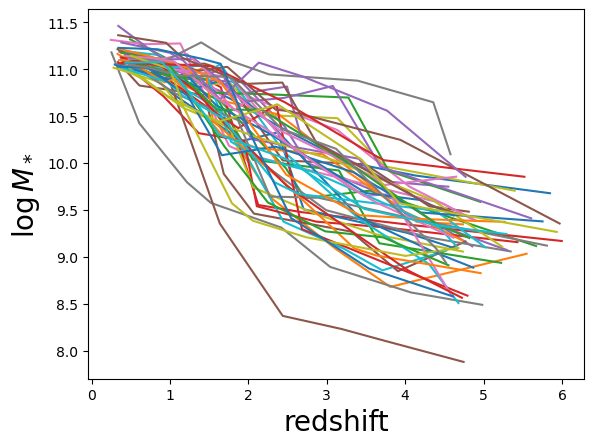

In [11]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,0]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log M_*$',fontsize=20)

plt.savefig('mass_growth_CEERS.png')

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_17060\483030535.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log M_*$',fontsize=20)


(57, 8, 3)


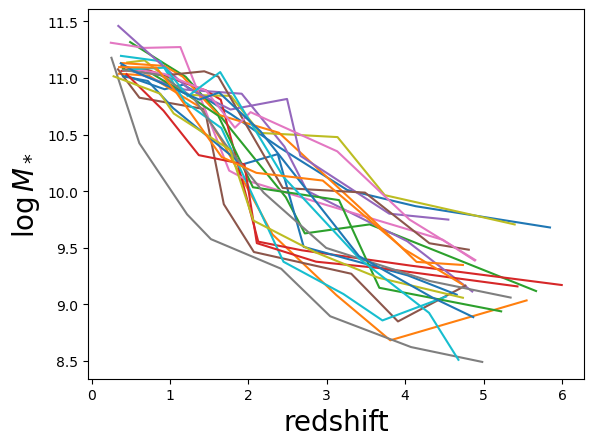

In [12]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,0]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log M_*$',fontsize=20)

plt.savefig('mass_growth_CEERS.png')

In [13]:
x_test = np.array(node_features['x'])
print((x_test[:,0,0]))

[11.021563  11.038116  11.317778  11.063323  11.089231  11.077337
 11.312008  11.179144  11.137631  11.195974  11.014995  11.132851
 11.084326  11.034384  11.460677  11.10715   11.089088  11.06968
 11.0153675 11.077488  11.130058  11.096325  11.192241  11.065427
 11.185348  11.213507  11.019097  11.038785  11.027899  11.037093
 11.049135  11.162033  11.172654  11.126216  11.134508  11.147104
 11.110711  11.118532  11.008709  11.019653  11.026943  11.213863
 11.075782  11.069033  11.284499  11.3618765 11.143061  11.044025
 11.143692  11.069117  11.226943  11.209592  11.030311  11.112554
 11.094447  11.089302  11.139275 ]


(57, 8, 3)


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_17060\2706922235.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log Re$',fontsize=20)


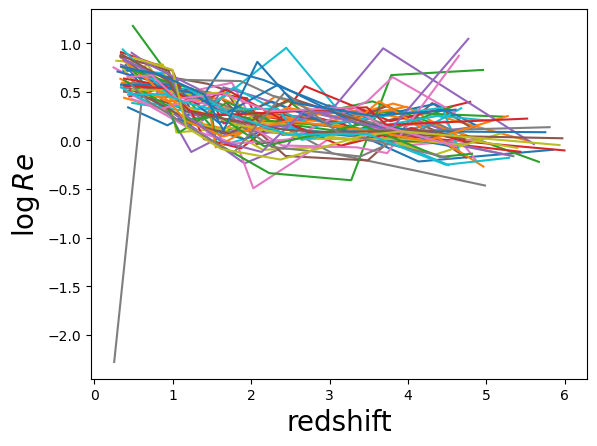

In [14]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,1]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log Re$',fontsize=20)

plt.savefig('re_growth_CEERS.png')

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_17060\3075396213.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log Re$',fontsize=20)


(57, 8, 3)


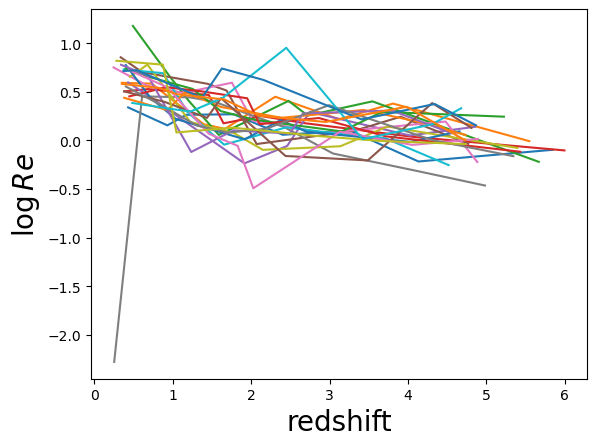

In [15]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,1]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log Re$',fontsize=20)

plt.savefig('re_growth_CEERS.png')

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_17060\3426603825.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log SFR$',fontsize=20)


(57, 8, 3)


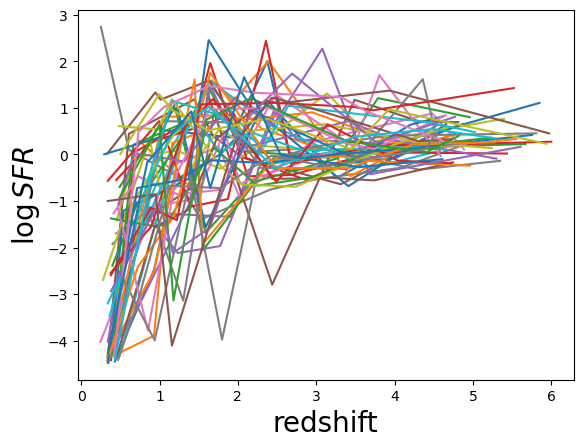

In [16]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

plt.savefig('sfr_growth_CEERS.png')

### graficas grandes

<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
C:\Users\usuario\AppData\Local\Temp\ipykernel_17060\3646879630.py:36: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log$ SFR', fontsize=20)


Shapes: (176,) (176,)
[-3.04245812 -0.9084472  -0.27643643  0.47034768  0.20053446  0.00343516
  0.12927145  0.36487294]


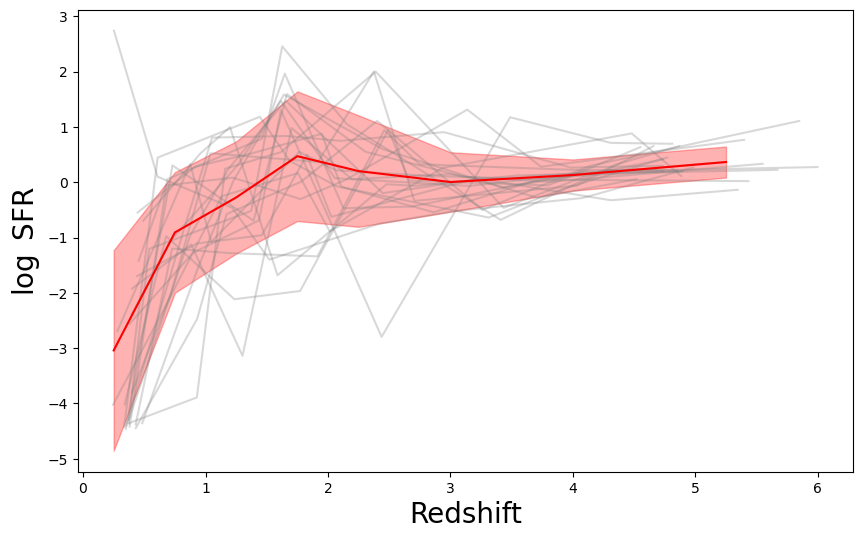

In [17]:
plt.figure(figsize=[10, 6])

all_sfrs = []
all_redshifts = []

for i in range(22):  # Assuming you have 51 entries based on your example
    redshifts = 1 / np.array(node_features['t'][i]) - 1
    sfr = np.array(node_features['x'][i][:, 2])
    plt.plot(redshifts, sfr, color='gray', alpha=0.3)

    all_redshifts.extend(redshifts)
    all_sfrs.extend(sfr)

# Make sure the data is in the correct numpy array format
all_redshifts_np = np.squeeze(np.array(all_redshifts))
all_sfrs_np = np.array(all_sfrs)

valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
filtered_redshifts = all_redshifts_np[valid_data_mask]
filtered_sfrs = all_sfrs_np[valid_data_mask]

# Verify shapes
print("Shapes:", all_redshifts_np.shape, all_sfrs_np.shape)

# Binning the data
bin_edges = np.array([0,0.5,1.,1.5,2,2.5,3.5,4.5,6])
bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.plot(bin_centers, bin_means, color='red')
print(bin_means)
plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color='red', alpha=0.3)

plt.xlabel('Redshift', fontsize=20)
plt.ylabel('$\log$ SFR', fontsize=20)

plt.savefig('sfr_growth_CEERS_modified.png')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\usuario\\Documents\\TFG\\likelihood_COSMOS_SFR\\node_features_morphology\\node_features_9.8_10.pkl'

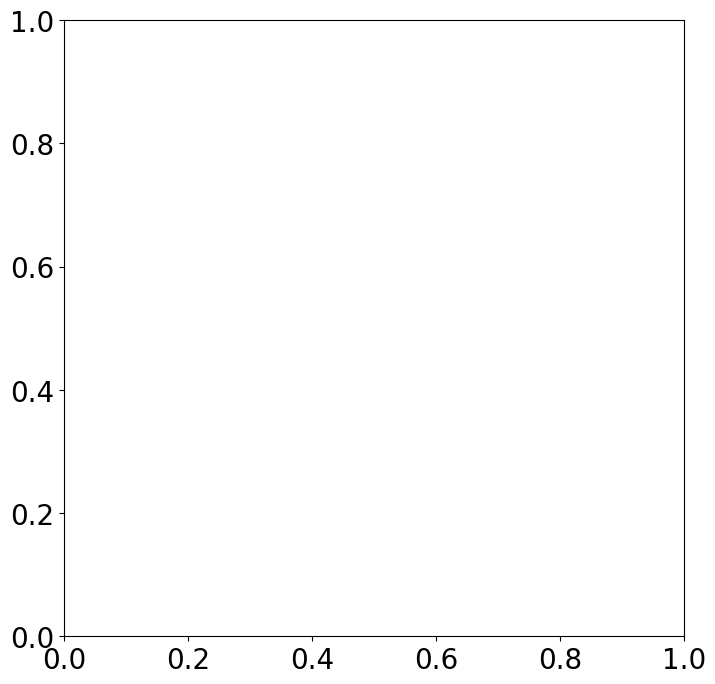

In [18]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8, 10], [10, 10.2], [10.2, 10.4], [10.4, 10.6], [10.6, 10.8], [10.8, 11], [11, 12]]

colors = ['red', 'orange', 'green', 'dodgerblue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel(r'$\log$ SFR', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
nbins=12
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []
   

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        t = np.array(node_features['t'][i])
        cosmic_times = Planck15.age(redshifts)
        sfr = 10**np.array(node_features['x'][i][:, 2])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)
plt.legend(loc='upper right',fontsize=15)
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
nbins=12
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
#colors = ['blue', 'green', 'purple', 'orange','pink','brown','black']  # Adjust or add more colors for each mass bin
#SFH_path = "/Users/marchuertascompany/Documents/data/COSMOS-Web/automnt/n17data/arango/CIGALE/runs/run_web/COSMOSWEB_1.6_INPUT/out/" 
#### Para mi sfh_path es el path a datos2

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []
   

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(1):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        print(redshifts)
        t = np.array(node_features['t'][i])
        cosmic_times = Planck15.age(redshifts)
        sfr = 10**np.array(node_features['x'][i][:, 2])

        id_val = node_features['id'][i][0, 0]  # Ensure this is how your ID is structured
        print(id_val)
        file_name = f"{id_val}_SFH.fits"
        with fits.open(datos2_data_path+file_name) as hdul:
            data = hdul[1].data  # Assuming the table is in the first extension; adjust if different

            # Convert to a Pandas DataFrame
            sfh_fit = pd.DataFrame({ 'time': data['time'], 'SFR': data['SFR'] })
            print(sfh_fit.time.values)
        plt.plot(cosmic_times, sfr, color='black',label='Florah')  # Use the same color for individual lines, with some alpha
        plt.plot(sfh_fit.time.values*1e-3+cosmic_times[0].value-len(sfh_fit.time.values)*1e-3,sfh_fit.SFR.values,color='red',label='SED fit')
       

        # Finalizing the plot
        plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
        plt.ylabel('SFR ($M_\odot.yr^{-1}$)', fontsize=20)
        plt.legend(loc='upper right',fontsize=15)
        plt.savefig('sfr_growth_CEERS_combined.png')
        plt.show()


In [ ]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 0])
        
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('$\log M_*/M_\odot$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['sersic'][i])
        
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))
    print(all_sfrs_np.shape)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('Sersic index', fontsize=20)
plt.legend(loc='lower right')
#plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['x'][i][:, 0])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic time ($Gyrs$)', fontsize=20)
plt.ylabel('$\log M_*/M_\odot$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
nbins=10
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
#mass_bin = [[10, 10.3], [10.3, 10.6], [10.6, 10.9], [11, 12]]
#colors = ['blue', 'green', 'purple', 'orange']  # Adjust or add more colors for each mass bin
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(10**node_features['x'][i][:, 0]/10**node_features['x'][i][0, 0])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic time ($Gyrs$)', fontsize=20)
plt.ylabel('$M_*(t)/M_*(t_H)$', fontsize=20)
plt.legend(loc='lower right')
#plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins=9
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['sersic'][i])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Sersic Index', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins=12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts)
        sfr = np.array(node_features['bovert'][i])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('B/T', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
nbins = 12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path + f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts).value  # Make sure to extract value if it's a Quantity
        morphology = np.array(node_features['morphology'][i])

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(morphology)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})', lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Replace numerical y-axis values with labels
plt.yticks([0, 1, 2, 3], ['E', 'S', 'I', 'B+D'])

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Morphology', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('morphology_evolution.png')
plt.show()


In [ ]:
# Setup for plotting and data
nbins = 12
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 
morphology_mapping = {0: 0, 3: 1, 1: 2, 2: 3}


plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

for m_bin, color in zip(mass_bin, colors):
    with open(nfm_data_path + f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_morphologies = []
    all_cosmic_times = []

    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        cosmic_times = Planck15.age(redshifts).value  # convert to Gyr
        morphologies = np.array(node_features['morphology'][i])
        remapped_morphologies = np.vectorize(morphology_mapping.get)(morphologies)  # Remap the morphologies

        all_cosmic_times.extend(cosmic_times)
        all_morphologies.extend(remapped_morphologies)

    all_cosmic_times_np = np.array(all_cosmic_times)
    all_morphologies_np = np.array(all_morphologies)

    valid_data_mask = ~np.isnan(all_cosmic_times_np) & ~np.isnan(all_morphologies_np)
    filtered_cosmic_times = all_cosmic_times_np[valid_data_mask]
    filtered_morphologies = all_morphologies_np[valid_data_mask]

    bin_means, bin_edges, _ = stats.binned_statistic(filtered_cosmic_times, filtered_morphologies, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_cosmic_times, filtered_morphologies, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})', lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Set custom y-axis labels
morphology_labels = ['E', 'B+D', 'S', 'I']
plt.yticks(range(4), morphology_labels)

plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Morphology', fontsize=20)
plt.legend(loc='lower right', fontsize=12)
plt.savefig('morphology_evolution_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5,4, 4.5,5,5.5, 6])
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        #plt.plot(redshifts, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(ssfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np #[valid_data_mask]
    filtered_sfrs = all_sfrs_np #[valid_data_mask]

    # Binning the data
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('$\log$ sSFR', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins = 15
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        mstar = np.array(node_features['x'][i][:, 0])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        plt.plot(mstar, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(mstar)
        all_sfrs.extend(ssfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    #valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np
    filtered_sfrs = all_sfrs_np

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('$\log M_*/M_\odot$', fontsize=20)
plt.ylabel('$\log$ sSFR', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
#bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
nbins = 10
mass_bin = [[9.8,10],[10,10.2],[10.2,10.4],[10.4,10.6],[10.6,10.8],[10.8,11],[11,12]]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features['t'])):
        redshifts = 1 / np.array(node_features['t'][i]) - 1
        sfr = np.array(node_features['x'][i][:, 2])
        re = np.array(node_features['x'][i][:, 1])
        mstar = np.array(node_features['x'][i][:, 0])
        ssfr = np.log10(10**np.array(node_features['x'][i][:, 2])/10**np.array(node_features['x'][i][:, 0]))
        #plt.plot(mstar, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(mstar)
        all_sfrs.extend(re)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    #valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np
    filtered_sfrs = all_sfrs_np

    # Binning the data
    bin_means, bin_edges, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=nbins)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=f'$\log M_*/M_\odot:$ ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('$\log M_*/M_\odot$', fontsize=20)
plt.ylabel('$\log R_e$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig('sfr_growth_CEERS_combined.png')
plt.show()


### graficas chiquitas de nuevo


In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

plt.savefig('sfr_growth_CEERS.png')

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

#plt.savefig('sfr_growth_CEERS.png')

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)

#plt.savefig('sfr_growth_CEERS.png')

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(51):
    ssfr = np.log10(10**np.array(node_features['x'][i][:,2])/10**np.array(node_features['x'][i][:,0]))
    plt.plot(np.array(node_features['x'][i][:,0]),ssfr)

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log sSFR$',fontsize=20)

#plt.savefig('sfr_growth_CEERS.png')

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(22):
    ssfr = np.log10(10**np.array(node_features['x'][i][:,2])/10**np.array(node_features['x'][i][:,0]))
    plt.plot(np.array(node_features['x'][i][:,0]),ssfr)

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log sSFR$',fontsize=20)

#plt.savefig('sfr_growth_CEERS.png')

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(80):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,10**np.array(node_features['x'][i][:,0])/10**np.array(node_features['x'][i][0,0]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log M_*$',fontsize=20)


print(node_features['ra'][11][0][0])
print(node_features['dec'][11][0])

plt.savefig('mass_growth_CEERS.png')

## A partir de aquí mirar:

In [ ]:
q = cosmos_cat.query('RA_1>=214.88161 and RA_1<=214.88163 and DEC_1>=52.88396 and DEC_1<=52.88398') ###### RA_1 = ra, DEC_1 = dec
q = cosmos_cat.query('RA_1>='+str(node_features['ra'][i][0][0]-1e-5)+' and RA_1<='+str(node_features['ra'][i][0][0]+1e-5)+' and DEC_1>='+str(node_features['dec'][i][0][0]-1e-5)+' and DEC_1<='+str(node_features['ra'][i][0][0]+1e-5))
#print(q.ID_1)

In [ ]:
"""densebasis_dir = '/Users/marchuertascompany/Documents/data/CEERS/DenseBasis/'
db_cat = pd.read_csv(densebasis_dir + "CEERS_v0.51_dense_basis.csv")



#os.listdir(densebasis_dir)
#db_cat = Table.read(densebasis_dir + "CEERS_v0.51_dense_basis.fits", format='ascii.commented_header')

""" ##### Cambiar datos por los de cosmos

In [ ]:
from astropy.cosmology import Planck13,z_at_value
import astropy.units as u

cosmos_sel = cosmos_cat.query('ID == 19566')
sfh=cosmos_sel.sfh_50.values[0]
time = cosmos_sel.timeax.values[0]

# Remove the parentheses and split the string by comma
sfh = sfh.strip('()').split(',')
time = time.strip('()').split(',')

# Convert the strings to float numbers
numbers = [float(num) for num in sfh]
numbers_time = [float(num) for num in time]

# Convert the list of numbers to a NumPy array
sfh_array = np.array(numbers)
time_array = np.array(numbers_time)



cosmo = Planck13

# Convert time to redshift
# Convert time to redshift

print(cosmo.age)

redshift_array = np.array([z_at_value(cosmo.age, (t) * u.Gyr) for t in time_array[1:]])

sfh_array = sfh_array[1:]
plt.plot(redshift_array[redshift_array<5],np.log10(sfh_array[redshift_array<5]))

print(np.array(node_features['x']).shape)
node_features['t'][0]


plt.plot(1/ np.array(node_features['t'][11]) - 1,np.array(node_features['x'][11][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)  

In [ ]:
from astropy.cosmology import Planck13, z_at_value
import astropy.units as u



# Create a 2x5 grid of subplots (10 panels)
fig, axs = plt.subplots(2, 5, figsize=(15, 6))

first_obj = 68

for i in range(10):
    q = cosmos_cat.query(
        'RA_1>=' + str(node_features['ra'][first_obj+i][0][0] - 1e-5) + ' and RA_1<=' + str(node_features['ra'][first_obj+i][0][0] + 1e-5) +
        ' and DEC_1>=' + str(node_features['dec'][first_obj+i][0][0] - 1e-5) + ' and DEC_1<=' + str(node_features['dec'][first_obj+i][0][0] + 1e-5))


    print(q['ID_1'].values)
    cosmos_sel = cosmos_cat.query('ID == ' + str(q['ID_1'].values[0]))
    sfh = cosmos_sel.sfh_50.values[0]
    sfh_16 = cosmos_sel.sfh_16.values[0]
    sfh_84 = cosmos_sel.sfh_84.values[0]
    time = cosmos_sel.timeax.values[0]

    # Remove the parentheses and split the string by comma
    sfh = sfh.strip('()').split(',')
    sfh_16 = sfh_16.strip('()').split(',')
    sfh_84 = sfh_84.strip('()').split(',')
    time = time.strip('()').split(',')

    # Convert the strings to float numbers
    numbers = [float(num) for num in sfh]
    numbers_16 = [float(num) for num in sfh_16]
    numbers_84 = [float(num) for num in sfh_84]
    numbers_time = [float(num) for num in time]

    # Convert the list of numbers to a NumPy array
    sfh_array = np.array(numbers)
    sfh_array_16 = np.array(numbers_16)
    sfh_array_84 = np.array(numbers_84)
    time_array = np.array(numbers_time)

    cosmo = Planck13

    # Convert time to redshift
    redshift_array = np.array([z_at_value(cosmo.age, t * u.Gyr) for t in time_array[1:]])

    sfh_array = sfh_array[1:]
    #print(sfh_array[1:])
    sfh_array_16 = sfh_array_16[1:]
    sfh_array_84 = sfh_array_84[1:]

    # Determine the subplot location in the 2x5 grid
    row = i // 5
    col = i % 5

    # Plot the data on the current subplot
    #axs[row, col].plot(redshift_array[redshift_array < 5], np.log10(sfh_array[redshift_array < 5]))
    axs[row, col].fill_between(redshift_array[redshift_array < 6], np.log10(sfh_array_16[redshift_array < 6]),np.log10(sfh_array_84[redshift_array < 6]),color='red',alpha=0.5,label='DenseBasis')
    axs[row, col].set_title(f'ID '+str(q['ID_1'].values[0]))
    axs[row, col].plot(1/ np.array(node_features['t'][first_obj+i]) - 1,np.array(node_features['x'][first_obj+i][:,2]),lw=4,color='black',label='Florah')
    axs[row, col].legend(loc='lower right')
    axs[row, col].set_ylim((-4,2.5))
# Set common labels for the entire figure
fig.text(0.5, 0.001, 'Redshift', ha='center', fontsize=20)
fig.text(0.001, 0.5, '$\log SFR$', va='center', rotation='vertical', fontsize=20)

# Adjust subplot layout and show the figure
plt.tight_layout()
plt.savefig('SFH_comparisons.png')
plt.show()


In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import match_coordinates_sky

c = SkyCoord(ra=ra1*u.degree, dec=dec1*u.degree)

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(10):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,1]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log R_e$',fontsize=20)    

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(1):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)      

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(20):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)    

In [ ]:
print(np.array(node_features['x']).shape)
node_features['t'][0]

for i in range(20):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,1]))


plt.xlabel('$\log M_*/M_\odot$',fontsize=20)

plt.ylabel('$\log Re$',fontsize=20)   